#  Speaker Diarization — AMI Corpus (10 Meetings)
### Stage 1: Audio Preprocessing → CNN Triplet Training → Embedding Extraction
---
> **Pipeline overview:**  
> Raw WAV files → sliding windows → log-mel features → CNN triplet training → 256-dim speaker embeddings  
> These embeddings feed into the Transformer encoder.

In [ ]:

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import IPython.display as ipd
import xml.etree.ElementTree as ET
import random
import zipfile
import os
import h5py
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from scipy.optimize import linear_sum_assignment

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

with zipfile.ZipFile("/content/drive/MyDrive/AMI_Corpus.zip", 'r') as z:
    z.extractall("/content/AMI_Corpus")

with zipfile.ZipFile("/content/drive/MyDrive/ami_public_manual_1.6.2.zip", 'r') as z:
    z.extractall("/content/ami_manual")

DATA_ROOT    = Path("/content/AMI_Corpus/AMI_Corpus")
OUTPUT_ROOT  = Path("/content/processed_data")
OUTPUT_ROOT.mkdir(exist_ok=True)

meetings = [f for f in DATA_ROOT.iterdir() if f.is_dir()]
meetings.sort(key=lambda f: f.name)

print(f"Meetings found: {len(meetings)}")
print([m.name for m in meetings])

Mounted at /content/drive
Meetings found: 10
['EN2001a', 'EN2002a', 'EN2003a', 'EN2004a', 'EN2005a', 'EN2009b', 'IB4001', 'IN1001', 'IS1000a', 'TS3003a']


In [ ]:
def load_audio(meeting_path, target_sr=16000):
    audio_dir = meeting_path / "audio"
    if not audio_dir.exists():
        return None, None, None

    tracks = {}
    for f in audio_dir.glob("*.wav"):
        for channel in range(5):
            if f"Headset-{channel}" in f.name:
                audio, sr = librosa.load(f, sr=target_sr, mono=True)
                tracks[f"Headset-{channel}"] = audio
                break

    if not tracks:
        return None, None, None

    print(f"  {meeting_path.name}: found {list(tracks.keys())}")

    min_len = min(len(a) for a in tracks.values())
    tracks  = {s: a[:min_len] for s, a in tracks.items()}
    mixed   = np.sum(list(tracks.values()), axis=0)
    mixed   = mixed / (np.max(np.abs(mixed)) + 1e-8)

    return mixed, tracks, target_sr


def sliding_windows(audio, sr, window_sec=3.0, hop_sec=1.5):
    window_size = int(window_sec * sr)
    hop_size    = int(hop_sec * sr)
    windows     = []
    for start in range(0, len(audio) - window_size, hop_size):
        end = start + window_size
        windows.append({
            "start_time": start / sr,
            "end_time":   end   / sr,
            "audio":      audio[start:end]
        })
    return windows


def compute_rms(audio):
    return np.sqrt(np.mean(audio ** 2))

In [ ]:
SILENCE_THRESHOLD = 0.00078
audio_dir  = OUTPUT_ROOT / "windows_audio"
logmel_dir = OUTPUT_ROOT / "logmel_features"
audio_dir.mkdir(exist_ok=True)
logmel_dir.mkdir(exist_ok=True)

def extract_log_mel(audio, sr=16000, n_mels=128):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, hop_length=512)
    return librosa.power_to_db(mel, ref=np.max)

rows = []

for meeting in tqdm(meetings, desc="Processing meetings"):
    mixed, tracks, sr = load_audio(meeting)
    if mixed is None:
        continue

    windows = sliding_windows(mixed, sr , 3.0 , 1.5)

    for i, w in enumerate(windows):
        chunk = w["audio"]
        rms   = compute_rms(chunk)

        # Save raw audio window
        audio_path = audio_dir / f"{meeting.name}_w{i}.npy"
        np.save(audio_path, chunk)

        # Save log-mel feature
        logmel_path = logmel_dir / f"{meeting.name}_w{i}.npy"
        np.save(logmel_path, extract_log_mel(chunk))

        rows.append({
            "meeting":      meeting.name,
            "window_idx":   i,
            "start_time":   w["start_time"],
            "end_time":     w["end_time"],
            "rms":          rms,
            "is_silent":    int(rms < SILENCE_THRESHOLD),
            "audio_path":   str(audio_path),
            "feature_path": str(logmel_path)
        })

df_windows = pd.DataFrame(rows)
df_windows.to_csv(OUTPUT_ROOT / "windows_metadata.csv", index=False)

print(f"Total windows: {len(df_windows)}")
print(f"Silent:        {df_windows['is_silent'].sum()} ({df_windows['is_silent'].mean()*100:.1f}%)")

Processing meetings:   0%|          | 0/10 [00:00<?, ?it/s]

  EN2001a: found ['Headset-2', 'Headset-4', 'Headset-0', 'Headset-1', 'Headset-3']


Processing meetings:  10%|█         | 1/10 [01:12<10:54, 72.74s/it]

  EN2002a: found ['Headset-2', 'Headset-1', 'Headset-0', 'Headset-3']


Processing meetings:  20%|██        | 2/10 [01:34<05:43, 42.88s/it]

...

  IS1000a: found ['Headset-3', 'Headset-2', 'Headset-0', 'Headset-1']


Processing meetings:  90%|█████████ | 9/10 [04:47<00:25, 25.21s/it]

  TS3003a: found ['Headset-0', 'Headset-1', 'Headset-3', 'Headset-2']


Processing meetings: 100%|██████████| 10/10 [04:58<00:00, 29.89s/it]


Total windows: 19521
Silent:        368 (1.9%)


In [ ]:
#save for whisper
import soundfile as sf

audio_drive_dir = Path("/content/drive/MyDrive/ami_audio")
audio_drive_dir.mkdir(exist_ok=True)

for meeting_path in tqdm(meetings, desc="Saving mixed audio to Drive"):
    out_path = audio_drive_dir / f"{meeting_path.name}_mixed.wav"

    if out_path.exists():
        print(f"  {meeting_path.name} already exists, skipping")
        continue

    mixed, tracks, sr = load_audio(meeting_path)
    if mixed is None:
        print(f"  {meeting_path.name} — no audio found")
        continue

    sf.write(str(out_path), mixed, sr)
    print(f"  Saved {meeting_path.name}_mixed.wav ({len(mixed)/sr:.1f}s)")

print(f"\nDone — {len(list(audio_drive_dir.glob('*.wav')))} WAV files in Drive")

Saving mixed audio to Drive:   0%|          | 0/10 [00:00<?, ?it/s]

  EN2001a: found ['Headset-2', 'Headset-4', 'Headset-0', 'Headset-1', 'Headset-3']


Saving mixed audio to Drive:  10%|█         | 1/10 [00:13<02:02, 13.57s/it]

  Saved EN2001a_mixed.wav (5250.2s)
  EN2002a: found ['Headset-2', 'Headset-1', 'Headset-0', 'Headset-3']


Saving mixed audio to Drive:  20%|██        | 2/10 [00:18<01:06,  8.31s/it]

...

  Saved IN1001_mixed.wav (3463.7s)
  IS1000a: found ['Headset-3', 'Headset-2', 'Headset-0', 'Headset-1']


Saving mixed audio to Drive:  90%|█████████ | 9/10 [01:01<00:05,  5.70s/it]

  Saved IS1000a_mixed.wav (1582.6s)
  TS3003a: found ['Headset-0', 'Headset-1', 'Headset-3', 'Headset-2']


Saving mixed audio to Drive: 100%|██████████| 10/10 [01:04<00:00,  6.42s/it]

  Saved TS3003a_mixed.wav (1505.6s)

Done — 10 WAV files in Drive


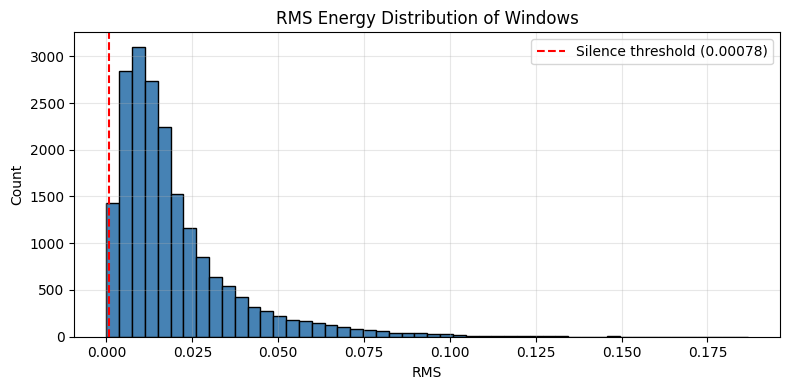

In [ ]:
# RMS Distribution Plot

plt.figure(figsize=(8, 4))
plt.hist(df_windows["rms"], bins=50, color="steelblue", edgecolor="black")
plt.axvline(SILENCE_THRESHOLD, color="red", linestyle="--",
            label=f"Silence threshold ({SILENCE_THRESHOLD})")
plt.title("RMS Energy Distribution of Windows")
plt.xlabel("RMS")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
for w in windows:
    w["rms"] = compute_rms(w["audio"])
    w["is_silent"] = w["rms"] < SILENCE_THRESHOLD

silent_count = sum(w["is_silent"] for w in windows)

print("Total windows:", len(windows))
print("Silent windows:", silent_count)
print("Silent %:", silent_count / len(windows) * 100)

Total windows: 1002
Silent windows: 64
Silent %: 6.387225548902195


In [ ]:

meeting = meetings[9]
mixed, tracks, sr = load_audio(meeting)

print("Meeting:", meeting.name)

windows = sliding_windows(mixed, sr)

print("Total windows:", len(windows))
for i in range(5):
    w = windows[i]
    print(f"Window {i}: {w['start_time']:.2f}s → {w['end_time']:.2f}s")

for i in range(min(5, len(windows))):
    print(f"Window {i} audio:")
    ipd.display(ipd.Audio(windows[i]["audio"], rate=sr))

  TS3003a: found ['Headset-0', 'Headset-2', 'Headset-1', 'Headset-3']
Meeting: TS3003a
Total windows: 1002
Window 0: 0.00s → 3.00s
Window 1: 1.50s → 4.50s
Window 2: 3.00s → 6.00s
Window 3: 4.50s → 7.50s
Window 4: 6.00s → 9.00s
Window 0 audio:


Window 1 audio:


Window 2 audio:


Window 3 audio:


Window 4 audio:


In [ ]:
#XML Speaker Label Parsing
segments_dir = Path("/content/ami_manual/segments")
your_meetings = ['EN2001a','EN2002a','EN2003a','EN2004a','EN2005a',
                 'EN2009b','IB4001','IN1001','IS1000a','TS3003a']

seg_files = sorted(segments_dir.glob("*.xml"))
matched   = [f for f in seg_files if any(m in f.name for m in your_meetings)]
print(f"Matched segment files: {len(matched)}")

def parse_segments(xml_path):
    tree = ET.parse(xml_path)
    return [
        (float(s.attrib["transcriber_start"]), float(s.attrib["transcriber_end"]))
        for s in tree.getroot().findall("segment")
    ]

def get_dominant_speaker(window_start, window_end, speaker_segments):
    best_speaker, best_overlap = "silence", 0.0
    for speaker, segs in speaker_segments.items():
        overlap = sum(
            max(0, min(window_end, seg_end) - max(window_start, seg_start))
            for seg_start, seg_end in segs
        )
        if overlap > best_overlap:
            best_overlap = overlap
            best_speaker = speaker
    return best_speaker, best_overlap

Matched segment files: 41


In [ ]:
# Build Labeled Dataset
rows_labeled = []

for _, row in tqdm(df_windows.iterrows(), total=len(df_windows)):  # FIX: was df_windows_cnn
    meeting = row["meeting"]

    speaker_segments = {}
    for f in [f for f in matched if meeting in f.name]:
        speaker = f.name.split(".")[1]
        speaker_segments[speaker] = parse_segments(f)

    dominant_speaker, overlap = get_dominant_speaker(
        row["start_time"], row["end_time"], speaker_segments
    )

    rows_labeled.append({
        "meeting":        meeting,
        "window_idx":     row["window_idx"],
        "start_time":     row["start_time"],
        "end_time":       row["end_time"],
        "rms":            row["rms"],
        "is_silent":      row["is_silent"],
        "feature_path":   row["feature_path"],
        "speaker_id":     f"{meeting}.{dominant_speaker}",  # global ID
        "speech_overlap": overlap
    })

df_labeled = pd.DataFrame(rows_labeled)

le = LabelEncoder()
df_labeled["speaker_label"] = le.fit_transform(df_labeled["speaker_id"])
speaker_classes = list(le.classes_)

df_labeled.to_csv(OUTPUT_ROOT / "labeled_CNN_metadata.csv", index=False)
pd.Series(speaker_classes).to_csv(OUTPUT_ROOT / "speaker_classes.csv",
                                   index=True, header=["speaker_id"])

df_windows_cnn = df_labeled

print(f"Total windows:   {len(df_labeled)}")
print(f"Unique speakers: {len(speaker_classes)}")
print(f"Silence windows: {df_labeled['speaker_id'].str.contains('silence').sum()}")
df_labeled.head()

100%|██████████| 19521/19521 [02:09<00:00, 150.70it/s]


Total windows:   19521
Unique speakers: 48
Silence windows: 957


,meeting,window_idx,start_time,end_time,rms,is_silent,feature_path,speaker_id,speech_overlap,speaker_label
0,EN2001a,0,0.0,3.0,0.007704,0,/content/processed_data/logmel_features/EN2001...,EN2001a.silence,0.000,5
1,EN2001a,1,1.5,4.5,0.003226,0,/content/processed_data/logmel_features/EN2001...,EN2001a.E,0.800,4
2,EN2001a,2,3.0,6.0,0.004147,0,/content/processed_data/logmel_features/EN2001...,EN2001a.E,1.337,4
3,EN2001a,3,4.5,7.5,0.005411,0,/content/processed_data/logmel_features/EN2001...,EN2001a.E,0.640,4
4,EN2001a,4,6.0,9.0,0.004572,0,/content/processed_data/logmel_features/EN2001...,EN2001a.E,0.103,4


In [ ]:
#CNN Encoder + TripletDataset

class CNNEncoder(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        x = self.pool(self.net(x)).view(x.size(0), -1)
        return nn.functional.normalize(self.fc(x), p=2, dim=1)


class TripletDataset(Dataset):
    def __init__(self, df, seed=None):
        self.df = df.reset_index(drop=True)
        self.rng = random.Random(seed)

        self.speech_df = self.df[
            ~self.df["speaker_id"].str.contains("silence")
        ].reset_index(drop=True)

        self.speaker_groups = {
            spk: self.speech_df[self.speech_df["speaker_id"] == spk].index.tolist()
            for spk in self.speech_df["speaker_id"].unique()
        }

        self.speakers = [s for s in self.speaker_groups if len(self.speaker_groups[s]) > 1]
        self.speech_df = self.speech_df[
            self.speech_df["speaker_id"].isin(self.speakers)
        ].reset_index(drop=True)

        self.speaker_groups = {
            spk: self.speech_df[self.speech_df["speaker_id"] == spk].index.tolist()
            for spk in self.speakers
        }

        print(f"  Speakers: {len(self.speakers)} | Windows: {len(self.speech_df)}")

    def __len__(self):
        return len(self.speech_df)

    def load_mel(self, path, augment=False):
        mel = np.load(path)
        if augment:
            # time masking
            t  = random.randint(0, mel.shape[1] // 8)
            t0 = random.randint(0, mel.shape[1] - t)
            mel[:, t0:t0+t] = mel.mean()
            # frequency masking
            f  = random.randint(0, mel.shape[0] // 8)
            f0 = random.randint(0, mel.shape[0] - f)
            mel[f0:f0+f, :] = mel.mean()
            # gain jitter
            mel += np.random.uniform(-2.0, 2.0)
        return torch.tensor(mel, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        anchor  = self.speech_df.iloc[idx]
        anc_spk = anchor["speaker_id"]

        anc_mel = self.load_mel(anchor["feature_path"])

        pos_candidates = [i for i in self.speaker_groups[anc_spk] if i != idx]
        if len(pos_candidates) <= 2:
            pos_idx = self.rng.choice(pos_candidates)
        else:
            sample  = self.rng.sample(pos_candidates, min(5, len(pos_candidates)))
            pos_idx = max(
                sample,
                key=lambda i: torch.nn.functional.mse_loss(
                    anc_mel, self.load_mel(self.speech_df.iloc[i]["feature_path"])
                ).item()
            )

        neg_spk        = self.rng.choice([s for s in self.speakers if s != anc_spk])
        neg_candidates = self.rng.sample(
            self.speaker_groups[neg_spk],
            min(5, len(self.speaker_groups[neg_spk]))
        )

        pos_mel  = self.load_mel(self.speech_df.iloc[pos_idx]["feature_path"])
        pos_dist = torch.nn.functional.mse_loss(anc_mel, pos_mel).item()

        neg_dists  = [
            (i, torch.nn.functional.mse_loss(
                anc_mel, self.load_mel(self.speech_df.iloc[i]["feature_path"])
            ).item())
            for i in neg_candidates
        ]
        semi_hard = [i for i, d in neg_dists if d > pos_dist]
        neg_idx   = self.rng.choice(semi_hard) if semi_hard else min(neg_dists, key=lambda x: x[1])[0]

        return (
            self.load_mel(anchor["feature_path"], augment=True),
            self.load_mel(self.speech_df.iloc[pos_idx]["feature_path"], augment=True),
            self.load_mel(self.speech_df.iloc[neg_idx]["feature_path"], augment=False),
        )


# Sanity check
cnn      = CNNEncoder(embedding_dim=256).to(device)
test_out = cnn(torch.randn(4, 1, 128, 93).to(device))
print("CNN output shape:", test_out.shape)
print("L2 norm:",          test_out.norm(dim=1).mean().item())

CNN output shape: torch.Size([4, 256])
L2 norm: 1.0


In [ ]:
df = pd.read_csv(OUTPUT_ROOT / "labeled_CNN_metadata.csv")

df_speech = df[~df["speaker_id"].str.contains("silence")].reset_index(drop=True)

train_meetings = ['EN2001a','EN2002a','EN2003a','EN2004a','EN2005a','EN2009b','IB4001']
val_meetings   = ['IN1001']
test_meetings  = ['IS1000a','TS3003a']

df_train = df_speech[df_speech["meeting"].isin(train_meetings)].reset_index(drop=True)
df_val   = df_speech[df_speech["meeting"].isin(val_meetings)].reset_index(drop=True)
df_test  = df_speech[df_speech["meeting"].isin(test_meetings)].reset_index(drop=True)

print("Train meetings:", df_train["meeting"].unique())
print("Val meetings:",   df_val["meeting"].unique())
print("Test meetings:",  df_test["meeting"].unique())
print(f"\nTrain: {len(df_train)} windows | {df_train['speaker_id'].nunique()} speakers")
print(f"Val:   {len(df_val)} windows   | {df_val['speaker_id'].nunique()} speakers")
print(f"Test:  {len(df_test)} windows  | {df_test['speaker_id'].nunique()} speakers")

Train meetings: ['EN2001a' 'EN2002a' 'EN2003a' 'EN2004a' 'EN2005a' 'EN2009b' 'IB4001']
Val meetings: ['IN1001']
Test meetings: ['IS1000a' 'TS3003a']

Train: 14586 windows | 27 speakers
Val:   2220 windows   | 3 speakers
Test:  1758 windows  | 8 speakers


## CNN Triplet Training

| Hyperparameter | Value |
|---|---|
| Epochs | 20 |
| Batch Size | 64 |
| Learning Rate | 1e-4 |
| Margin | 0.3 |
| Patience | 4 |
| Optimizer | Adam + weight decay 1e-4 |


In [ ]:
EPOCHS     = 20
BATCH_SIZE = 64
LR         = 1e-4
MARGIN     = 0.3
PATIENCE   = 4

cnn       = CNNEncoder(embedding_dim=256).to(device)
criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer = optim.Adam(cnn.parameters(), lr=LR, weight_decay=1e-4)  # FIX: added weight_decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_loader = DataLoader(TripletDataset(df_train), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TripletDataset(df_val),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

train_losses, val_losses = [], []
best_val         = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    cnn.train()
    train_loss = 0.0
    for anc, pos, neg in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        loss = criterion(cnn(anc), cnn(pos), cnn(neg))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    cnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for anc, pos, neg in val_loader:
            anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
            val_loss += criterion(cnn(anc), cnn(pos), cnn(neg)).item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    if avg_val < best_val:
        best_val          = avg_val
        epochs_no_improve = 0
        torch.save(cnn.state_dict(), "/content/drive/MyDrive/cnn_best.pth")
        print(f"  ✓ Best model saved (val={best_val:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} — no improvement for {PATIENCE} epochs")
            break

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

print(f"\nBest val loss: {best_val:.4f}")

  Speakers: 27 | Windows: 14586
  Speakers: 3 | Windows: 2220


Epoch 1/20 [Train]: 100%|██████████| 228/228 [01:42<00:00,  2.22it/s]


  ✓ Best model saved (val=0.3506)
Epoch 1/20 | Train: 0.2604 | Val: 0.3506 | LR: 0.000100


Epoch 2/20 [Train]: 100%|██████████| 228/228 [01:31<00:00,  2.48it/s]


  ✓ Best model saved (val=0.2796)
Epoch 2/20 | Train: 0.1912 | Val: 0.2796 | LR: 0.000100


...

Epoch 4/20 | Train: 0.0091 | Val: 0.3048 | LR: 0.000100


Epoch 5/20 [Train]: 100%|██████████| 228/228 [01:31<00:00,  2.48it/s]


Epoch 5/20 | Train: 0.0013 | Val: 0.3062 | LR: 0.000100


Epoch 6/20 [Train]: 100%|██████████| 228/228 [01:34<00:00,  2.42it/s]



Early stopping at epoch 6 — no improvement for 4 epochs

Best val loss: 0.2796


batch 64 lr 0.0001  margin patience val loss 0.2796

batch 16 lr 0.0001  margin patience val loss 0.2798

batch 8 lr 0.00001  margin patience val loss 0.2902

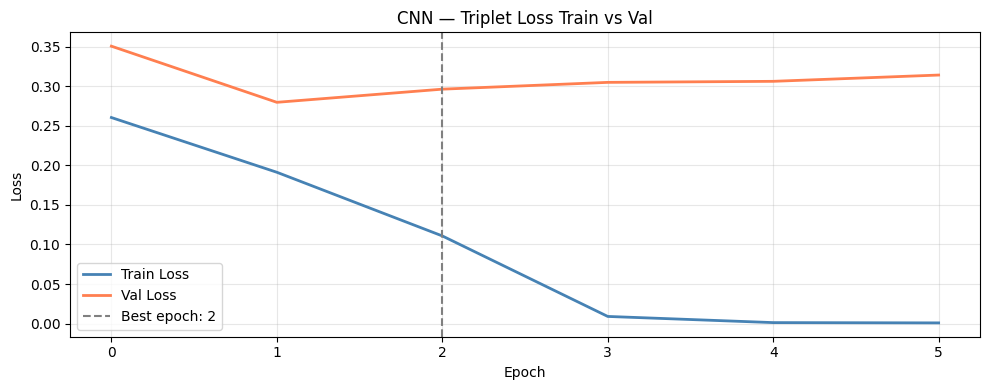

Best epoch: 2 | Best val loss: 0.2796


In [ ]:
# CNN Loss Plot

best_ep = val_losses.index(min(val_losses)) + 1
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(val_losses,   label="Val Loss",   color="coral",     linewidth=2)
plt.axvline(best_ep, color="gray", linestyle="--", label=f"Best epoch: {best_ep}")
plt.title("CNN — Triplet Loss Train vs Val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cnn_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best epoch: {best_ep} | Best val loss: {min(val_losses):.4f}")

In [ ]:
# CNN Triplet Accuracy

cnn.load_state_dict(torch.load("/content/drive/MyDrive/cnn_best.pth"))
cnn.eval()

test_loader = DataLoader(TripletDataset(df_test), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

for split_name, loader in [("Val", val_loader), ("Test", test_loader)]:
    correct = total = 0
    with torch.no_grad():
        for anc, pos, neg in loader:
            anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
            d_pos = (cnn(anc) - cnn(pos)).norm(dim=1)
            d_neg = (cnn(anc) - cnn(neg)).norm(dim=1)
            correct += (d_pos < d_neg).sum().item()
            total   += anc.size(0)
    print(f"{split_name} Triplet Accuracy: {correct/total*100:.2f}% ({correct}/{total})")

  Speakers: 8 | Windows: 1758
Val Triplet Accuracy: 58.11% (1290/2220)
Test Triplet Accuracy: 55.92% (983/1758)


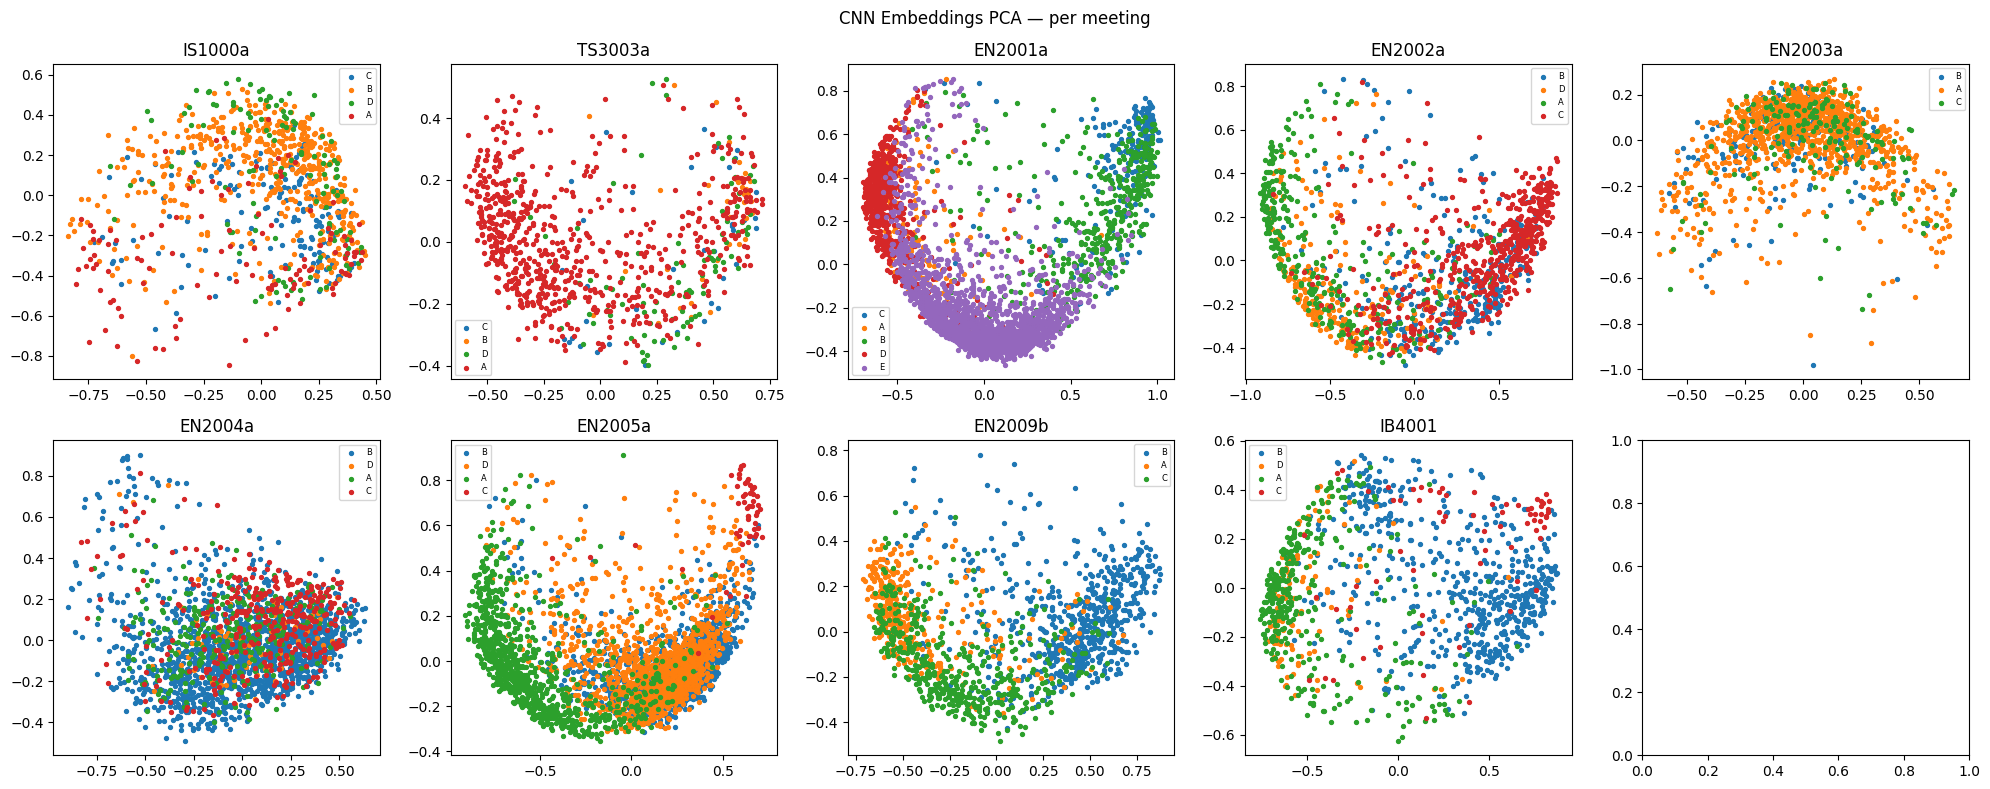

In [ ]:
# plot embedding separation per meeting to see if structure is there
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cnn.eval()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, meeting in zip(axes.flatten(), test_meetings + train_meetings[:8]):
    subset = df_speech[df_speech["meeting"] == meeting]

    embs, labels = [], []
    with torch.no_grad():
        for _, row in subset.iterrows():
            mel = torch.tensor(np.load(row["feature_path"]),
                             dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            embs.append(cnn(mel).squeeze(0).cpu().numpy())
            labels.append(row["speaker_id"].split(".")[-1])  # just letter

    embs = np.array(embs)
    X2d  = PCA(n_components=2).fit_transform(embs)

    for spk in set(labels):
        idx = [i for i, l in enumerate(labels) if l == spk]
        ax.scatter(X2d[idx, 0], X2d[idx, 1], s=8, label=spk)

    ax.set_title(meeting)
    ax.legend(fontsize=6)

plt.suptitle("CNN Embeddings PCA — per meeting")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

cnn.eval()

all_meetings = train_meetings + val_meetings + test_meetings  # add this

print("Meeting | True Speakers | Silhouette Score | Verdict")
print("-" * 60)

for meeting in all_meetings:
    subset = df_speech[df_speech["meeting"] == meeting].reset_index(drop=True)
    if len(subset) < 10:
        continue

    embs, labels = [], []
    with torch.no_grad():
        for _, row in subset.iterrows():
            mel = torch.tensor(
                np.load(row["feature_path"]), dtype=torch.float32
            ).unsqueeze(0).unsqueeze(0).to(device)
            embs.append(cnn(mel).squeeze(0).cpu().numpy())
            labels.append(row["speaker_id"])

    embs       = normalize(np.array(embs), norm="l2")
    n_speakers = len(set(labels))

    if n_speakers < 2:
        continue

    pred = AgglomerativeClustering(
        n_clusters=n_speakers,
        metric="cosine",
        linkage="average"
    ).fit_predict(embs)

    score = silhouette_score(embs, pred, metric="cosine")

    split   = "TRAIN" if meeting in train_meetings else ("VAL" if meeting in val_meetings else "TEST")
    verdict = "good" if score > 0.15 else "weak"
    print(f"{meeting} [{split}] | {n_speakers} speakers | {score:.3f} | {verdict}")

Meeting | True Speakers | Silhouette Score | Verdict
------------------------------------------------------------
EN2001a [TRAIN] | 5 speakers | 0.584 | good
EN2002a [TRAIN] | 4 speakers | 0.353 | good
EN2003a [TRAIN] | 3 speakers | 0.583 | good
EN2004a [TRAIN] | 4 speakers | 0.482 | good
EN2005a [TRAIN] | 4 speakers | 0.571 | good
EN2009b [TRAIN] | 3 speakers | 0.560 | good
IB4001 [TRAIN] | 4 speakers | 0.546 | good
IN1001 [VAL] | 3 speakers | 0.504 | good
IS1000a [TEST] | 4 speakers | 0.505 | good
TS3003a [TEST] | 4 speakers | 0.403 | good


In [ ]:
cnn.load_state_dict(torch.load("/content/drive/MyDrive/cnn_best.pth"))
cnn.eval()

emb_dir = OUTPUT_ROOT / "cnn_embeddings"
emb_dir.mkdir(exist_ok=True)

rows_emb = []

with torch.no_grad():
    for _, row in tqdm(df_speech.iterrows(), total=len(df_speech), desc="Extracting embeddings"):
        mel = torch.tensor(
            np.load(row["feature_path"]), dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0).to(device)

        emb = cnn(mel).squeeze(0).cpu().numpy()  # (256,)

        emb_path = emb_dir / f"{row['meeting']}_{row['window_idx']}.npy"
        np.save(emb_path, emb)

        rows_emb.append({
            "meeting":      row["meeting"],
            "window_idx":   row["window_idx"],
            "start_time":   row["start_time"],
            "end_time":     row["end_time"],
            "speaker_id":   row["speaker_id"],
            "emb_path":     str(emb_path)
        })

df_emb = pd.DataFrame(rows_emb)
df_emb.to_csv(OUTPUT_ROOT / "cnn_embeddings_meta.csv", index=False)

print(f"Saved {len(df_emb)} embeddings")


Extracting embeddings: 100%|██████████| 18564/18564 [00:38<00:00, 480.55it/s]


Saved 18564 embeddings


In [ ]:
print(df_emb.head())

   meeting  window_idx  start_time  end_time speaker_id  \
0  EN2001a           1         1.5       4.5  EN2001a.E   
1  EN2001a           2         3.0       6.0  EN2001a.E   
2  EN2001a           3         4.5       7.5  EN2001a.E   
3  EN2001a           4         6.0       9.0  EN2001a.E   
4  EN2001a           5         7.5      10.5  EN2001a.E   

                                            emb_path  
0  /content/processed_data/cnn_embeddings/EN2001a...  
1  /content/processed_data/cnn_embeddings/EN2001a...  
2  /content/processed_data/cnn_embeddings/EN2001a...  
3  /content/processed_data/cnn_embeddings/EN2001a...  
4  /content/processed_data/cnn_embeddings/EN2001a...  


In [ ]:
cnn.load_state_dict(torch.load("/content/drive/MyDrive/cnn_best.pth"))
cnn.eval()

emb_dir = Path("/content/processed_data/cnn_embeddings")
emb_dir.mkdir(exist_ok=True)

emb_drive_dir = Path("/content/drive/MyDrive/cnn_embeddings")
emb_drive_dir.mkdir(exist_ok=True)

# use df_labeled (ALL rows including silence) not df_speech
rows_emb = []

with torch.no_grad():
    for _, row in tqdm(df_labeled.iterrows(), total=len(df_labeled), desc="Extracting all embeddings"):
        mel_path = Path(row["feature_path"])
        if not mel_path.exists():
            continue

        mel = torch.tensor(
            np.load(mel_path), dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0).to(device)

        emb = cnn(mel).squeeze(0).cpu().numpy()  # (256,)

        emb_filename = f"{row['meeting']}_{row['window_idx']}.npy"
        emb_local    = emb_dir       / emb_filename
        emb_drive    = emb_drive_dir / emb_filename

        np.save(emb_local, emb)
        np.save(emb_drive, emb)

        rows_emb.append({
            "meeting":    row["meeting"],
            "window_idx": row["window_idx"],
            "start_time": row["start_time"],
            "end_time":   row["end_time"],
            "speaker_id": row["speaker_id"],
            "emb_path":   str(emb_local)
        })

df_emb_full = pd.DataFrame(rows_emb)
df_emb_full.to_csv("/content/drive/MyDrive/cnn_embeddings_meta.csv", index=False)
df_emb_full.to_csv("/content/processed_data/cnn_embeddings_meta.csv", index=False)

print(f"Saved {len(df_emb_full)} embeddings")
print(f"Expected ~18564, got {len(df_emb_full)}")

Extracting all embeddings: 100%|██████████| 19521/19521 [57:54<00:00,  5.62it/s]


Saved 19521 embeddings
Expected ~18564, got 19521


In [ ]:
import shutil
from pathlib import Path

shutil.copy(
    "/content/processed_data/cnn_embeddings_meta.csv",
    "/content/drive/MyDrive/cnn_embeddings_meta.csv"
)

emb_drive_dir = Path("/content/drive/MyDrive/cnn_embeddings")
emb_drive_dir.mkdir(exist_ok=True)

for emb_file in tqdm(list(Path("/content/processed_data/cnn_embeddings").glob("*.npy")), desc="Copying to Drive"):
    shutil.copy(emb_file, emb_drive_dir / emb_file.name)

print("Done — saved to Drive")

Copying to Drive: 100%|██████████| 19521/19521 [03:40<00:00, 88.38it/s]

Done — saved to Drive


In [ ]:
import os

# check drive
drive_csv   = "/content/drive/MyDrive/cnn_embeddings_meta.csv"
drive_embs  = list(Path("/content/drive/MyDrive/cnn_embeddings").glob("*.npy"))

print(f"CSV in Drive:       {os.path.exists(drive_csv)}")
print(f"Embeddings in Drive: {len(drive_embs)} files")

# check the CSV has all rows
if os.path.exists(drive_csv):
    df_check = pd.read_csv(drive_csv)
    print(f"CSV rows:           {len(df_check)}")
    print(f"Silence rows:       {df_check['speaker_id'].str.contains('silence').sum()}")

CSV in Drive:       True
Embeddings in Drive: 19521 files
CSV rows:           19521
Silence rows:       957


In [ ]:
print(f"Embeddings in Drive: {len(drive_embs)}")


Embeddings in Drive: 19521


In [ ]:
# verify the CSV matches what we expect
df_check = pd.read_csv("/content/drive/MyDrive/cnn_embeddings_meta.csv")

print(f"Total rows:    {len(df_check)}")
print(f"Silence rows:  {df_check['speaker_id'].str.contains('silence').sum()}")
print(f"Speech rows:   {(~df_check['speaker_id'].str.contains('silence')).sum()}")
print(f"Meetings:      {df_check['meeting'].nunique()}")
print(f"Unique files:  {df_check['emb_path'].nunique()}")

# check for duplicates
dupes = df_check.duplicated(subset=["meeting", "window_idx"])
print(f"Duplicate rows: {dupes.sum()}")

Total rows:    19521
Silence rows:  957
Speech rows:   18564
Meetings:      10
Unique files:  19521
Duplicate rows: 0


In [ ]:
# check what paths look like
print(df_check["emb_path"].head(10).tolist())
print("...")
print(df_check["emb_path"].tail(10).tolist())

['/content/processed_data/cnn_embeddings/EN2001a_0.npy', '/content/processed_data/cnn_embeddings/EN2001a_1.npy', '/content/processed_data/cnn_embeddings/EN2001a_2.npy', '/content/processed_data/cnn_embeddings/EN2001a_3.npy', '/content/processed_data/cnn_embeddings/EN2001a_4.npy', '/content/processed_data/cnn_embeddings/EN2001a_5.npy', '/content/processed_data/cnn_embeddings/EN2001a_6.npy', '/content/processed_data/cnn_embeddings/EN2001a_7.npy', '/content/processed_data/cnn_embeddings/EN2001a_8.npy', '/content/processed_data/cnn_embeddings/EN2001a_9.npy']
...
['/content/processed_data/cnn_embeddings/TS3003a_992.npy', '/content/processed_data/cnn_embeddings/TS3003a_993.npy', '/content/processed_data/cnn_embeddings/TS3003a_994.npy', '/content/processed_data/cnn_embeddings/TS3003a_995.npy', '/content/processed_data/cnn_embeddings/TS3003a_996.npy', '/content/processed_data/cnn_embeddings/TS3003a_997.npy', '/content/processed_data/cnn_embeddings/TS3003a_998.npy', '/content/processed_data/cnn

In [ ]:
df_clean = df_check.copy()

df_clean["emb_path"] = df_clean["emb_path"].apply(
    lambda p: str(Path("/content/drive/MyDrive/cnn_embeddings") / Path(p).name)
)

missing = df_clean[~df_clean["emb_path"].apply(lambda p: Path(p).exists())]
print(f"Missing after fix: {len(missing)}")
print(f"Total rows:        {len(df_clean)}")

df_clean.to_csv("/content/drive/MyDrive/cnn_embeddings_meta.csv", index=False)
print("Done")
print(df_clean["emb_path"].head(3).tolist())

Missing after fix: 0
Total rows:        19521
Done
['/content/drive/MyDrive/cnn_embeddings/EN2001a_0.npy', '/content/drive/MyDrive/cnn_embeddings/EN2001a_1.npy', '/content/drive/MyDrive/cnn_embeddings/EN2001a_2.npy']
